# Project Introduction

## Superstore Sales Analysis

This project analyzes sales performance using the Global Superstore dataset.
The goal is to identify sales trends, profitable product categories, and regional performance.

## 1. Import libraries and load data

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

df = pd.read_csv('C:/Users/Lenova/OneDrive/Documents/Data Analysis Projects/Global_Superstore.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          1000 non-null   int64  
 1   Order ID        1000 non-null   object 
 2   Order Date      1000 non-null   object 
 3   Ship Date       1000 non-null   object 
 4   Ship Mode       1000 non-null   object 
 5   Customer ID     1000 non-null   object 
 6   Customer Name   1000 non-null   object 
 7   Segment         1000 non-null   object 
 8   Postal Code     194 non-null    float64
 9   City            1000 non-null   object 
 10  State           1000 non-null   object 
 11  Country         1000 non-null   object 
 12  Region          1000 non-null   object 
 13  Market          1000 non-null   object 
 14  Product ID      1000 non-null   object 
 15  Category        1000 non-null   object 
 16  Sub-Category    1000 non-null   object 
 17  Product Name    1000 non-null   ob

In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Postal Code,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,40098,CA-2014-AB10015140-41954,11/11/2014,11/13/2014,First Class,AB-100151402,Aaron Bergman,Consumer,73120.0,Oklahoma City,...,TEC-PH-5816,Technology,Phones,Samsung Convoy 3,221.98,2,0.0,62.15,40.77,High
1,26341,IN-2014-JR162107-41675,02/05/2014,02/07/2014,Second Class,JR-162107,Justin Ritter,Corporate,NaN,Wollongong,...,FUR-CH-5379,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.40,9,0.1,-288.77,923.63,Critical
2,25330,IN-2014-CR127307-41929,10/17/2014,10/18/2014,First Class,CR-127307,Craig Reiter,Consumer,NaN,Brisbane,...,TEC-PH-5356,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.17,9,0.1,919.97,915.49,Medium
3,13524,ES-2014-KM1637548-41667,1/28/2014,1/30/2014,First Class,KM-1637548,Katherine Murray,Home Office,NaN,Berlin,...,TEC-PH-5267,Technology,Phones,"Motorola Smart Phone, Cordless",2892.51,5,0.1,-96.54,910.16,Medium
4,47221,SG-2014-RH9495111-41948,11/05/2014,11/06/2014,Same Day,RH-9495111,Rick Hansen,Consumer,NaN,Dakar,...,TEC-CO-6011,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.96,8,0.0,311.52,903.04,Critical


In [9]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,1000.000000,194.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,25079.328000,53966.170103,1710.971470,5.55800,0.092840,288.920440,272.384897
std,12897.726632,33734.306466,1259.239238,2.71846,0.148666,574.504782,176.160716
min,58.000000,2920.000000,1.910000,1.00000,0.000000,-3059.820000,1.070000
25%,15118.750000,19134.000000,826.907500,4.00000,0.000000,10.037500,209.827500
50%,25084.500000,60564.000000,1585.115000,5.00000,0.000000,190.685000,258.897500
75%,34524.000000,88187.500000,2477.812500,7.00000,0.150000,518.872500,351.070250
max,51284.000000,98198.000000,9892.740000,14.00000,0.800000,4946.370000,923.630000


## 2. Checking for NULL values

In [10]:
print(df.isnull().sum())

Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Postal Code       806
City                0
State               0
Country             0
Region              0
Market              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping Cost       0
Order Priority      0
dtype: int64


## 3. Handling the NULL Values in Postal Code

In [13]:
df['Postal Code'] = df['Postal Code'].fillna("Unknown")
df['Postal Code'] = df['Postal Code'].astype(str)

In [14]:
print(df.isnull().sum())

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Postal Code       0
City              0
State             0
Country           0
Region            0
Market            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
Shipping Cost     0
Order Priority    0
dtype: int64


## 4. Convert Dates 

In [15]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

## 5. Create Analytical Columns 

In [18]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

In [19]:
df[['Sales','Profit','Quantity','Discount']].describe()

,Sales,Profit,Quantity,Discount
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,1710.971470,288.920440,5.55800,0.092840
std,1259.239238,574.504782,2.71846,0.148666
min,1.910000,-3059.820000,1.00000,0.000000
25%,826.907500,10.037500,4.00000,0.000000
50%,1585.115000,190.685000,5.00000,0.000000
75%,2477.812500,518.872500,7.00000,0.150000
max,9892.740000,4946.370000,14.00000,0.800000


## 6. Sales trend over time

In [47]:
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()
yearly_sales

,Year,Sales
0,2012,293829.82
1,2013,352570.33
2,2014,456844.29
3,2015,607727.03


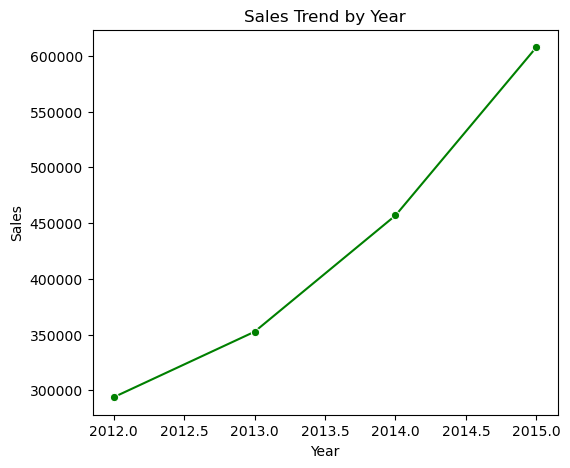

In [52]:
plt.figure(figsize=(6,5))

sns.lineplot(
    data=yearly_sales,
    x='Year',
    y='Sales',
    color='green',
    marker = 'o'
)

plt.title("Sales Trend by Year")
plt.ylabel("Sales")
plt.xlabel("Year")
plt.show()

### Insight: Sales increased steadily over time.

## 7. Monthly Sales Seasonality

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

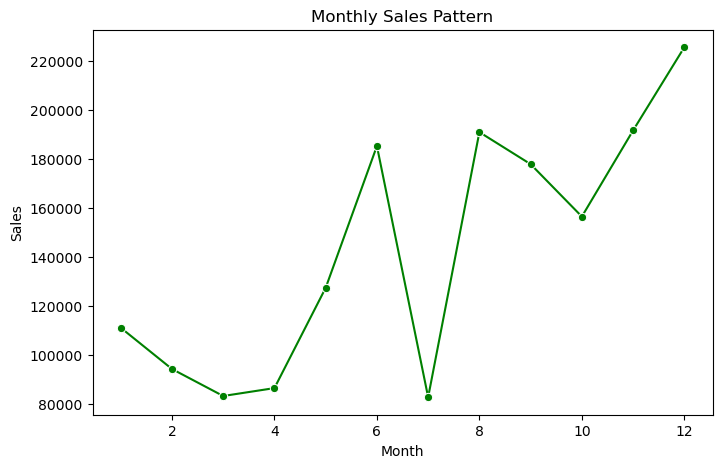

In [57]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))

sns.lineplot(data=monthly_sales, x='Month', y='Sales', color='green',marker='o')

plt.title("Monthly Sales Pattern")
plt.ylabel("Sales")
plt.xlabel("Month")
plt.show()

### Insights: Sales peak during the December months which shows the seasonality of the sales

## 8. Sales by region

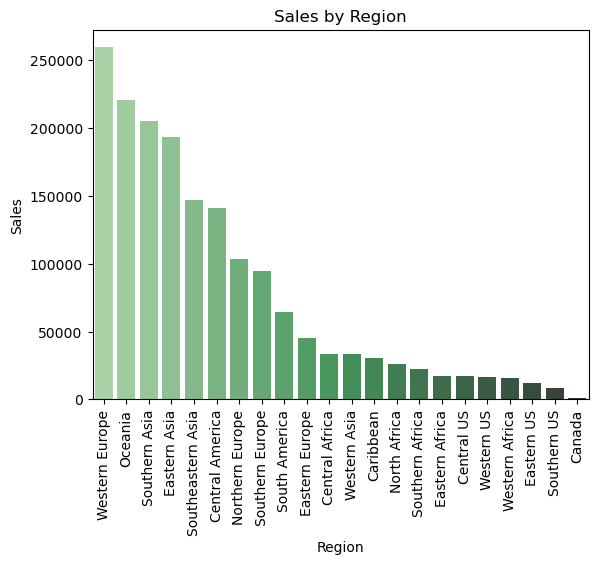

In [61]:
region_sales_df = df.groupby('Region')['Sales'].sum().reset_index()

# Sort values descending
region_sales_df = region_sales_df.sort_values('Sales', ascending=False)

# Create barplot with seaborn
sns.barplot(data=region_sales_df, x='Region', y='Sales',hue='Region', palette='Greens_d')

plt.title("Sales by Region")
plt.ylabel("Sales")
plt.xlabel("Region")
plt.xticks(rotation=90)  # Optional: rotate x labels if they overlap
plt.show()

### Insight: Clearly "Western Europe" is the region which generates high sales

## 9. Category performance

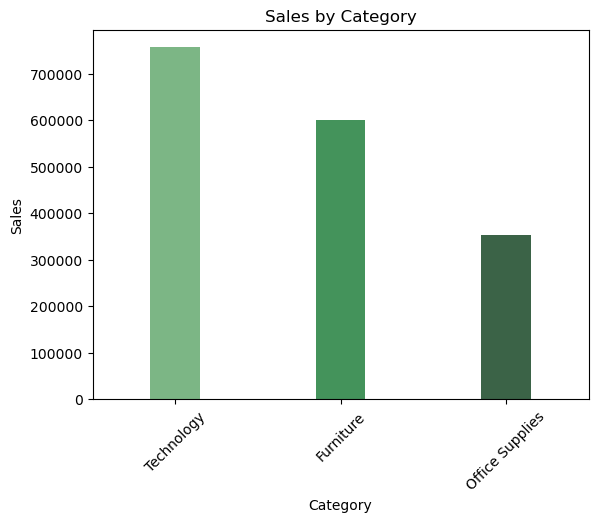

In [64]:
# Prepare data
category_sales_df = df.groupby('Category')['Sales'].sum().reset_index()
category_sales_df = category_sales_df.sort_values('Sales', ascending=False)

# Seaborn barplot with green shades
sns.barplot(
    data=category_sales_df,
    x='Category',
    y='Sales',
    hue='Category',       # required for palette in Seaborn 0.14+
    palette='Greens_d',
    dodge=False,
    legend=False,
    width = 0.3
)

plt.title("Sales by Category")
plt.ylabel("Sales")
plt.xlabel("Category")
plt.xticks(rotation=45)
plt.show()

In [24]:
## Profitability by Category

df.groupby('Category')['Profit'].sum()

Category
Furniture           82188.95
Office Supplies     61662.81
Technology         145068.68
Name: Profit, dtype: float64

### Insight: Technology often generates the highest revenue.

## 10. Top selling products

In [25]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_products)

Product Name
Motorola Smart Phone, Full Size                             48542.52
Apple Smart Phone, Full Size                                42303.44
Cisco Smart Phone, Full Size                                41325.20
Nokia Smart Phone, Full Size                                27661.97
Samsung Smart Phone, Cordless                               25438.59
Hoover Stove, Red                                           23477.81
Motorola Smart Phone, with Caller ID                        23239.44
Harbour Creations Executive Leather Armchair, Adjustable    22145.80
Cisco Smart Phone, with Caller ID                           22047.89
Cisco Smart Phone, Cordless                                 21954.87
Name: Sales, dtype: float64


## 11. Customer analysis

In [26]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

print(top_customers)

Customer Name
Adrian Barton      17307.24
Dave Poirier       12871.07
Vivek Grady        12800.38
Adam Bellavance    11465.85
Fred Hopkins       11294.06
Dave Brooks        10705.87
John Huston        10565.05
Brad Norvell       10367.92
Anne McFarland      9904.74
Susan Pistek        9548.94
Name: Sales, dtype: float64


## 12. Discount vs Profit analysis

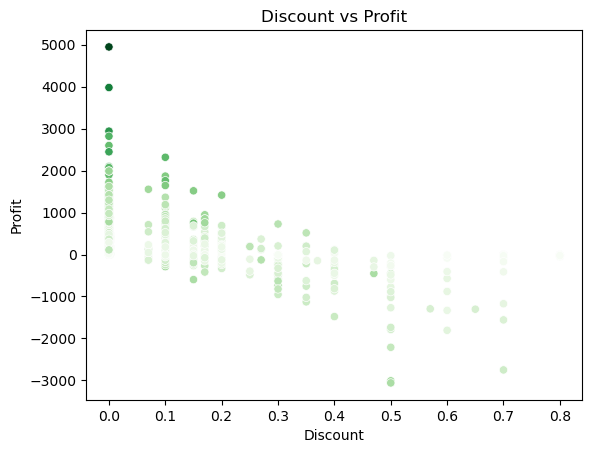

In [65]:
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Sales',         # variable controlling color
    palette='Greens',    # green gradient
    legend=False         # optional: hide legend
)

plt.title("Discount vs Profit")
plt.show()

### Insights: High discounts often lead to negative profit

## 13. Shipping performance

In [28]:
df.groupby('Ship Mode')['Shipping Days'].mean()

Ship Mode
First Class       2.088328
Same Day          0.019802
Second Class      2.807531
Standard Class    4.921283
Name: Shipping Days, dtype: float64

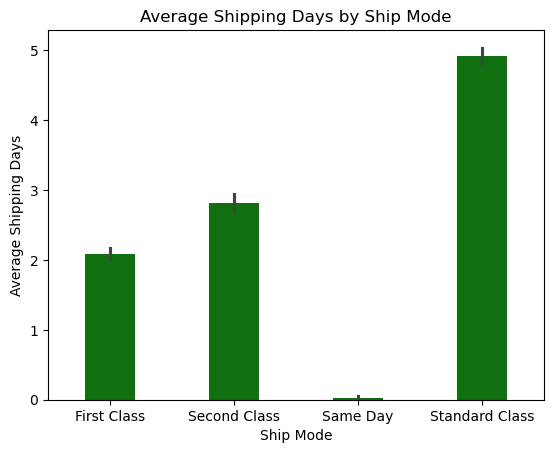

In [69]:
sns.barplot(data=df, x='Ship Mode', y='Shipping Days', estimator='mean', color = 'Green', width = 0.4)

plt.title("Average Shipping Days by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Shipping Days")

plt.show()

## 14.Profit by sub-category

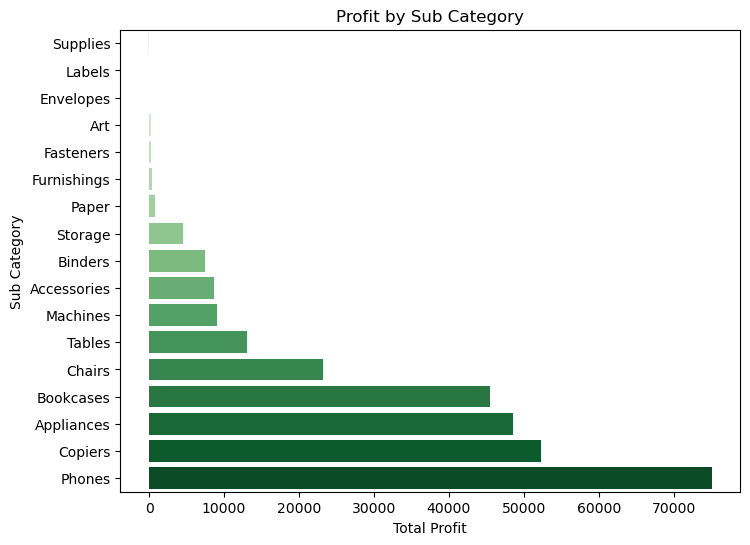

In [70]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values().reset_index()

plt.figure(figsize=(8,6))

sns.barplot(
    data=sub_profit,
    x='Profit',
    y='Sub-Category',
    hue='Sub-Category',
    palette='Greens',
    legend=False
)
plt.title("Profit by Sub Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub Category")

plt.show()

In [32]:
profit_subcategory = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

print(profit_subcategory)

Sub-Category
Phones         75119.47
Copiers        52315.19
Appliances     48518.99
Bookcases      45483.14
Chairs         23245.88
Tables         13051.69
Machines        8992.06
Accessories     8641.96
Binders         7435.09
Storage         4490.04
Paper            806.32
Furnishings      408.24
Fasteners        246.47
Art              191.87
Envelopes         42.02
Labels            21.86
Supplies         -89.85
Name: Profit, dtype: float64


### Insight: The most profitable sub-category is "Phones"

In [35]:
top_products = df.groupby('Product Name')['Sales'].sum() \
                 .sort_values(ascending=False) \
                 .head(10) \
                 .reset_index()

print(top_products)

                                        Product Name     Sales
0                    Motorola Smart Phone, Full Size  48542.52
1                       Apple Smart Phone, Full Size  42303.44
2                       Cisco Smart Phone, Full Size  41325.20
3                       Nokia Smart Phone, Full Size  27661.97
4                      Samsung Smart Phone, Cordless  25438.59
5                                  Hoover Stove, Red  23477.81
6               Motorola Smart Phone, with Caller ID  23239.44
7  Harbour Creations Executive Leather Armchair, ...  22145.80
8                  Cisco Smart Phone, with Caller ID  22047.89
9                        Cisco Smart Phone, Cordless  21954.87


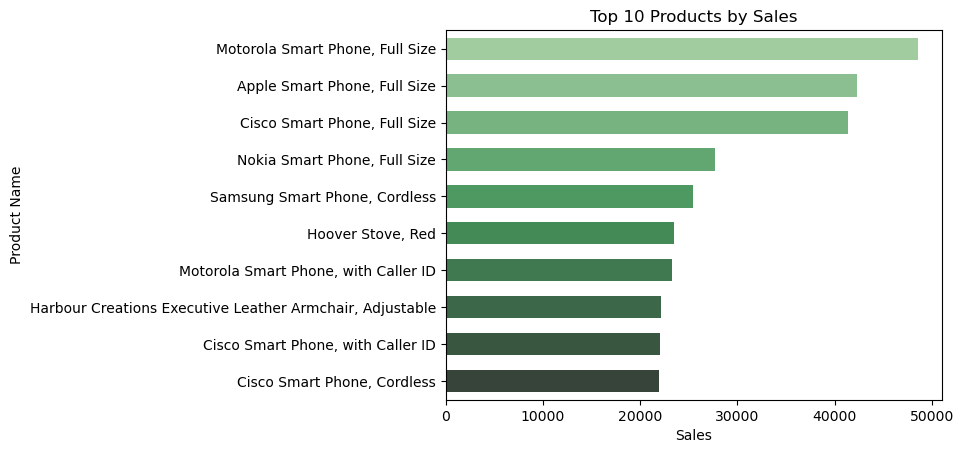

In [71]:
top_products = df.groupby('Product Name')['Sales'].sum() \
                 .sort_values(ascending=False) \
                 .head(10) \
                 .reset_index()

sns.barplot(
    data=top_products,
    x='Sales',
    y='Product Name',
    hue='Product Name',    # required to use palette
    palette='Greens_d',
    dodge=False,
    legend=False,
    width=0.6              # optional: narrower bars
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Name")
plt.show()